#### Question 1

**ISLP chapter 8 exercise #5**

**Suppose we produce ten bootstrapped samples from a data set
containing red and green classes. We then apply a classification tree
to each bootstrapped sample and, for a specific value of $X$, produce
10 estimates of $P(\text{Class is Red}|X):$**
$$0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, \text{and}\ 0.75.$$
**There are two common ways to combine these results together into a
single class prediction. One is the majority vote approach discussed in
this chapter. The second approach is to classify based on the average
probability. In this example, what is the final classification under each
of these two approaches?**

- For the majority vote, the fist 4 estimates predict the class is green and the last 6 predict the class is red. So, the final classification estimate is red.
- For the average probability, $\bar{P}(\text{Class is Red}|X)=0.45$. Accordingly, the final classification estimate is green.

***

#### Question 2

**Consider using gradient boosting to solve a regression problem.
Suppose that at each iteration, we fit the residuals using a “decision stump,”
that is, a decision tree with exactly two leaf nodes. Then, the final estimate
of the regression function can be expressed as**
$$\hat{f}(x)=\sum_{j=1}^p{\hat{f}_j(x_j)},$$
**where, for $j = 1,\dots,p$, $f_j$ is an arbitrary function of predictor $j$. Explain why
this is so.**

We initialize the the model as:
$$\hat{f}^{(0)}(x)=0$$
For $b=1, 2\dots B$, we update the model as:
$$\hat{f}^{(b)}(x)=\hat{f}^{(b-1)}(x)+\lambda h_b(x)$$
where,
- $\lambda>0$ is the learning rate
- $h_b(x)$ is the decision dump

For each $b$th iteration, the tree will only split at one variable, denoted as $x_{bj}$, then we have:
$$h_b(x)=h_b(x_{bj})$$
The final model is:
$$\hat{f}(x)=\sum_{b=1}^{B}{\lambda h_b(x_{bj})}$$
For each group, we define:
$$\hat{f}_j(x_j)=\sum_{b:j_b=j}{\lambda h_b(x_j)}$$
Then we have: 
$$\hat{f}(x)=\sum_{j=1}^p{\hat{f}_j(x_j)}$$

***

#### Question 3

**Create a sketch that illustrates the connection between a decision tree and the partition of input space that is implied by that decision tree. You can do this on paper (and scan it) or use a drawing program.**

**(a) Draw an example partition of a two-dimensional feature space that could
result from a tree with binary splits, with each feature defined on the
interval $[−1, 1]$. Include at least 5 regions.**

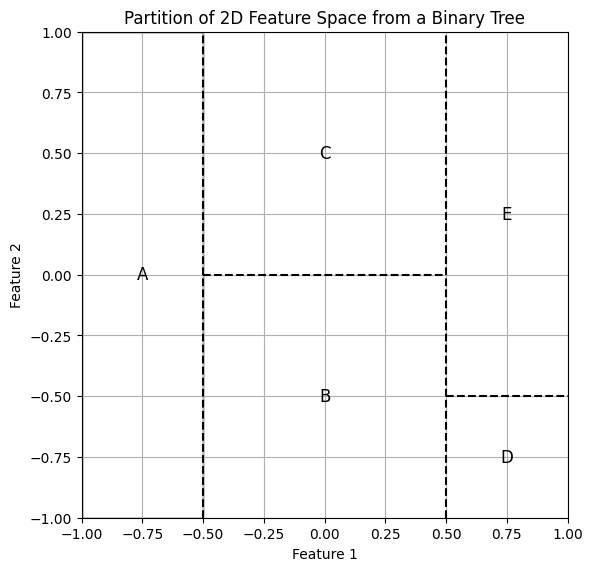

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Partition of 2D Feature Space from a Binary Tree")

# Region A: x <= -0.5
ax.add_patch(patches.Rectangle((-1, -1), 0.5, 2, fill=False, edgecolor='black'))
ax.text(-0.75, 0, "A", fontsize=12, ha='center', va='center')

# Region B: -0.5 < x <= 0.5 and y <= 0
ax.plot([-0.5, -0.5], [-1, 1], 'k--')  # vertical split at x = -0.5
ax.plot([0.5, 0.5], [-1, 1], 'k--')    # vertical split at x = 0.5
ax.plot([-0.5, 0.5], [0, 0], 'k--')    # horizontal split at y = 0

ax.text(0, -0.5, "B", fontsize=12, ha='center', va='center')  # bottom middle

# Region C: -0.5 < x <= 0.5 and y > 0
ax.text(0, 0.5, "C", fontsize=12, ha='center', va='center')   # top middle

# Region D: x > 0.5 and y <= -0.5
ax.plot([0.5, 1], [-0.5, -0.5], 'k--')  # horizontal split at y = -0.5
ax.text(0.75, -0.75, "D", fontsize=12, ha='center', va='center')

# Region E: x > 0.5 and y > -0.5
ax.text(0.75, 0.25, "E", fontsize=12, ha='center', va='center')

ax.grid(True)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


***

**(b) Draw a decision tree corresponding to the partition you drew, labeling
every tree branch. Show terminal nodes as rectangles and interior nodes
as circles. Do not include predictions at the terminal nodes, just the
branch labels (e.g. $X_1 < 0.5$)**

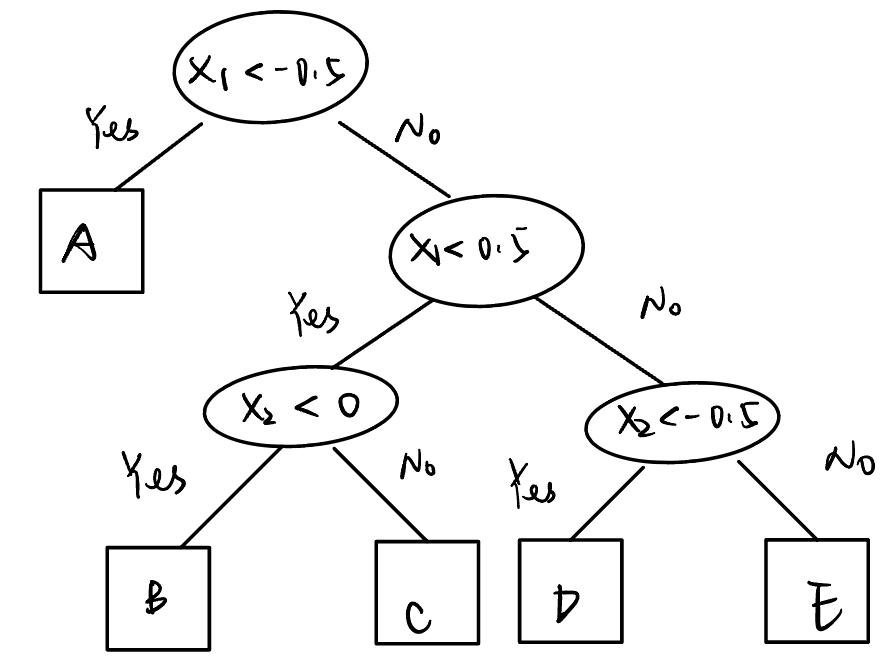

***

**（c) Draw the path of a particular point, with $X_1 = X_2 = 0.5$, through your
tree and label the terminal node where it ends up. Mark this point in
your plot from part (a) as well.**

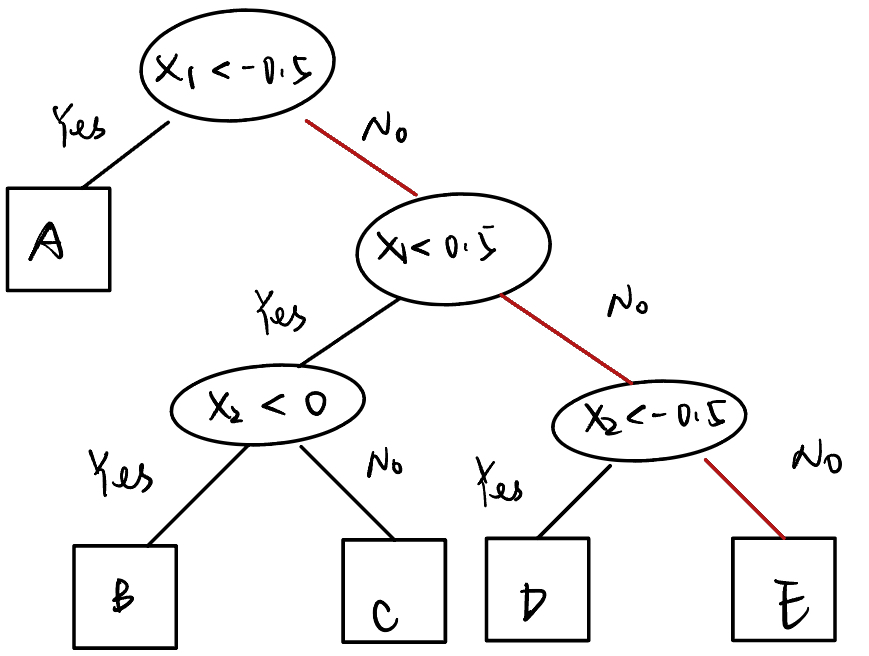

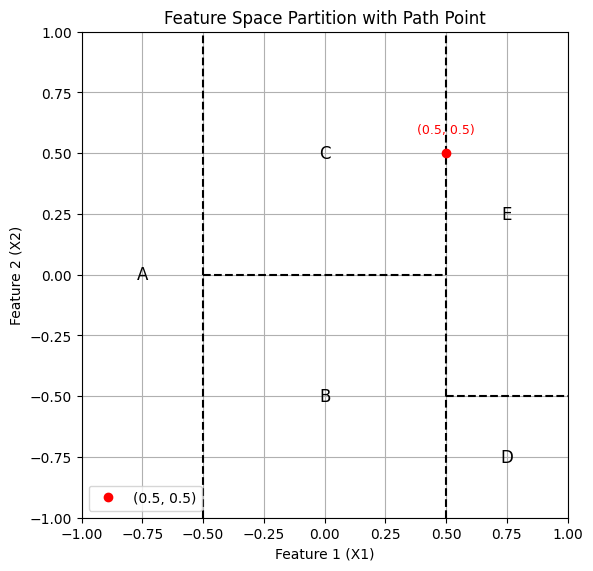

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Part (a): 2D feature space partition, with point (0.5, 0.5) added
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel("Feature 1 (X1)")
ax.set_ylabel("Feature 2 (X2)")
ax.set_title("Feature Space Partition with Path Point")

ax.plot([-0.5, -0.5], [-1, 1], 'k--')  # X1 = -0.5
ax.plot([0.5, 0.5], [-1, 1], 'k--')    # X1 = 0.5
ax.plot([-0.5, 0.5], [0, 0], 'k--')    # X2 = 0
ax.plot([0.5, 1], [-0.5, -0.5], 'k--') # X2 = -0.5

ax.text(-0.75, 0, "A", fontsize=12, ha='center', va='center')
ax.text(0, -0.5, "B", fontsize=12, ha='center', va='center')
ax.text(0, 0.5, "C", fontsize=12, ha='center', va='center')
ax.text(0.75, -0.75, "D", fontsize=12, ha='center', va='center')
ax.text(0.75, 0.25, "E", fontsize=12, ha='center', va='center')

ax.plot(0.5, 0.5, 'ro', label="(0.5, 0.5)")
ax.text(0.5, 0.58, "(0.5, 0.5)", color='red', fontsize=9, ha='center')

ax.grid(True)
ax.set_aspect('equal')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

#### Question 4

**Consider the crabs dataset, which is available from Canvas. This dataset contain five size-related measurements of two different species of crabs, blue and orange. 50 male and 50 female crabs of each species are measured. We will classify species based on the other predictor variables and evaluate errors in terms of the misclassification rate.**

**(a) Use `sklearn.model_selection.train_test_split` to split the data. Set the random state to 6789, the size of the training set to 80\% of the size of the entire dataset, and stratify according to species and sex so that approximately the same proportions of species/sex combinations appear in both the held-out and the training dataset.**

In [63]:
import pandas as pd
from sklearn.model_selection import train_test_split

crabs = pd.read_csv("crabs.csv", index_col=0)
crabs['group']= crabs['sp'] + "_" + crabs['sex']

train_df, test_df = train_test_split(crabs, train_size=0.8, random_state=6789, stratify=crabs["group"])

**(b) Train a classification tree to predict species from the five numerical measurements and sex. Select the max_leaf_nodes by cross-validation, considering the values {2, 3, . . . 10}. Plot the tree. Comment
on which variables are used by the tree. Compute training and test errors.**

The best max_leaf_nodes: 5


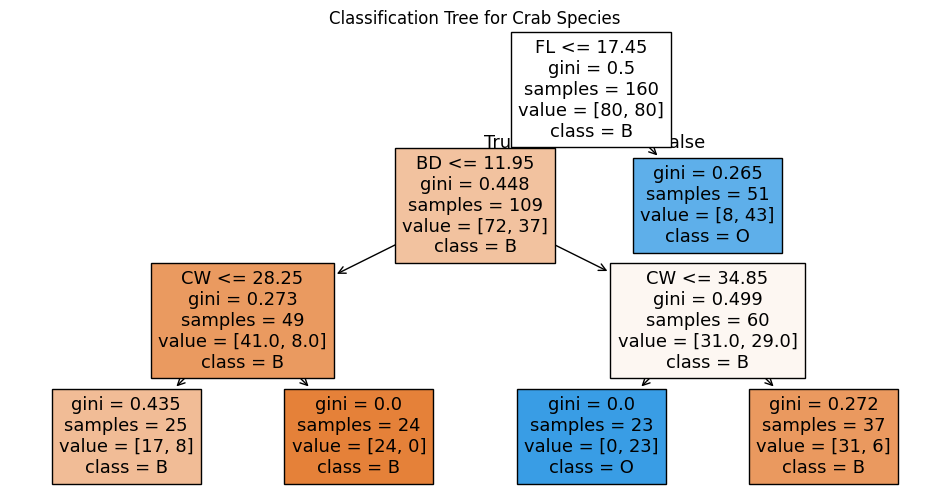

Training Error = 0.1375
Test Error = 0.3250


In [114]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

leaf_nodes = range(2, 11)
mean_cv_scores = []

X_train = train_df.drop(columns=['sp', 'index', 'group'])
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = test_df.drop(columns=['sp', 'index', 'group'])
X_test = pd.get_dummies(X_test, drop_first=True)
y_train = train_df['sp']
y_test = test_df['sp']

for leaf in leaf_nodes:
    tree = DecisionTreeClassifier(max_leaf_nodes=leaf, random_state=6789)
    scores = cross_val_score(tree, X_train, y_train, cv=5)
    mean_cv_scores.append(scores.mean())

# max_leaf_nodes param selection
best_leaf = leaf_nodes[np.argmax(mean_cv_scores)]
print(f"The best max_leaf_nodes: {best_leaf}")

final_tree = DecisionTreeClassifier(max_leaf_nodes=best_leaf, random_state=6789)
final_tree.fit(X_train, y_train)

#plot the tree
plt.figure(figsize=(12, 6))
plot_tree(final_tree, feature_names=X_train.columns, class_names=final_tree.classes_, filled=True)
plt.title("Classification Tree for Crab Species")
plt.show()

#Training and Test Error
train_pred = final_tree.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f"Training Error = {1-train_acc:.4f}")

test_pred = final_tree.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print(f"Test Error = {1-test_acc:.4f}")

**(c) Now, train a random forest with these data, using $m = 5$ randomly selected predictors for each split and 1000 trees in total. Make a variable importance plot and compare with your results for a single
tree. Compute training and test errors.**

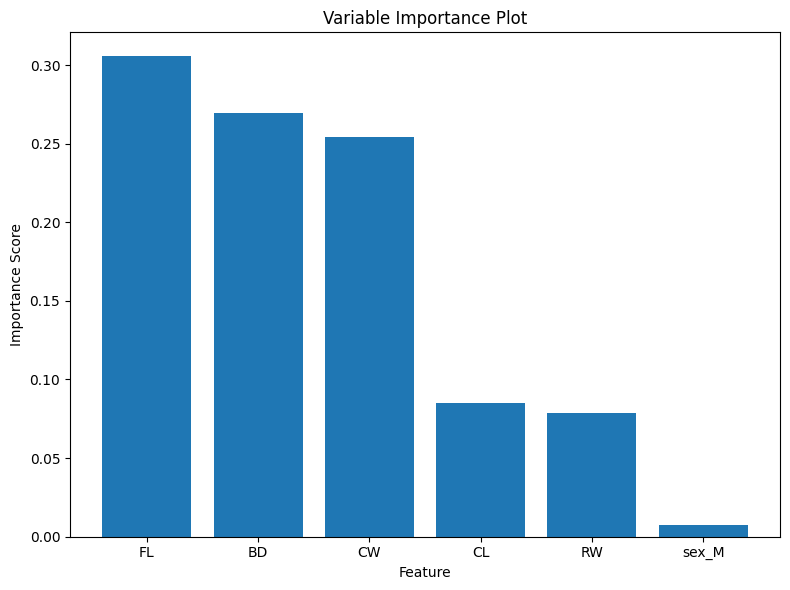

Training Error of Random Forest Model = 0.0
Test Error of Random Forest Model = 0.22499999999999998


In [118]:
from sklearn.ensemble import RandomForestClassifier

random_tree = RandomForestClassifier(n_estimators=1000, max_features=5, random_state=6789)
random_tree.fit(X_train, y_train)

features_name = X_train.columns
features_importance = random_tree.feature_importances_

# Sort feature importances in descending order
indices = np.argsort(features_importance)[::-1]

# Plot the feature importances of random forest
plt.figure(figsize=(8, 6))
plt.title("Variable Importance Plot")
plt.bar(range(len(features_name)), features_importance[indices], align="center")
plt.xticks(range(len(features_name)), [features_name[i] for i in indices], ha="center")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

#train and test error for random forest
train_pred_rf = random_tree.predict(X_train)
train_acc_rf = accuracy_score(y_train, train_pred_rf)
print(f"Training Error of Random Forest Model = {1-train_acc_rf}")

test_pred_rf = random_tree.predict(X_test)
test_acc_rf = accuracy_score(y_test,test_pred_rf)
print(f"Test Error of Random Forest Model = {1-test_acc_rf}")

Apparently, the error rates fo random forest are both lower on training set and test set than a single tree.

***

**(d) Fit `sklearn.ensemble.HistGradientBoostingClassifier` to the data. Plot the training and test error as a function of the number of trees M constructed by boosting, for a range of values of M up to 1000. Hint: Fit the tree only once using max_iter=1000 and then use `staged_predict` to calculate the error at each iteration. Report training and test errors for a value of M of your choice and justify why you chose that value.**

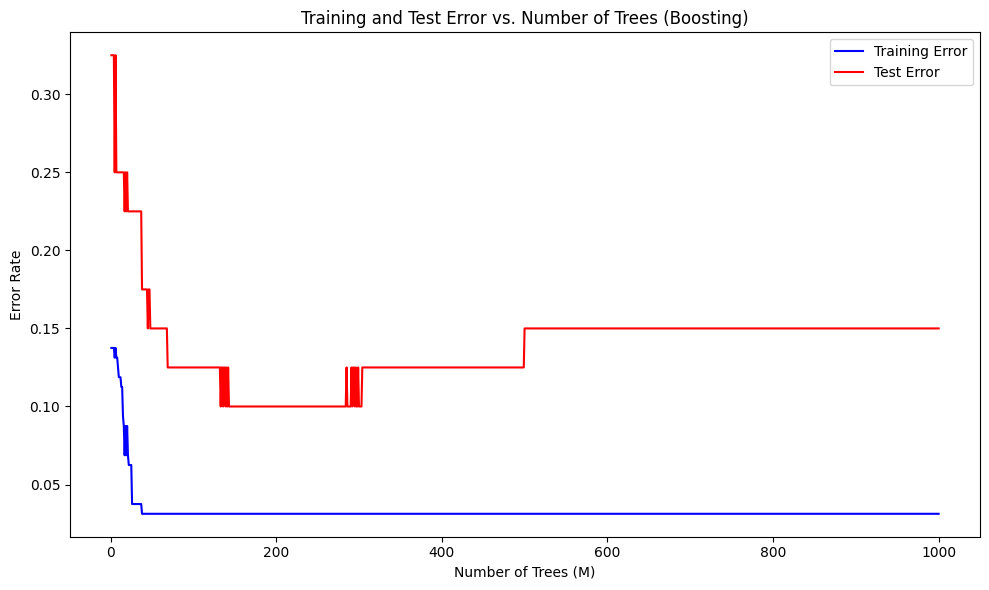

Best number of trees (M): 133
Training error at M=133: 0.0312
Test error at M=133: 0.1000


In [138]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgbc = HistGradientBoostingClassifier(max_iter=1000, random_state=6789)

hgbc.fit(X_train, y_train)

# Staged Predictions on Training Set
train_error = []
train_staged_pred = hgbc.staged_predict(X_train)
for train_pred in train_staged_pred:
    error_rate = 1 - accuracy_score(y_train, train_pred)
    train_error.append(error_rate)

# Staged Predictions on Test Set
test_error = []
test_staged_pred = hgbc.staged_predict(X_test)
for test_pred in test_staged_pred:
    error_rate = 1 - accuracy_score(y_test, test_pred)
    test_error.append(error_rate)

train_error = np.array(train_error)
test_error = np.array(test_error)
M = np.arange(1, 1001)

plt.figure(figsize=(10, 6))
plt.plot(M, train_error, label="Training Error", color='blue')
plt.plot(M, test_error, label="Test Error", color='red')
plt.xlabel("Number of Trees (M)")
plt.ylabel("Error Rate")
plt.title("Training and Test Error vs. Number of Trees (Boosting)")
plt.legend()
plt.tight_layout()
plt.show()

best_M = np.argmin(test_error) + 1
print(f"Best number of trees (M): {best_M}")
print(f"Training error at M={best_M}: {train_error[best_M-1]:.4f}")
print(f"Test error at M={best_M}: {test_error[best_M-1]:.4f}")

Choosing $M=133$ as test error first achieves the lowest value at this point.

***

**(e) Comment on which method appears to perform best for this dataset and whether the results (that is, training and test error) are consistent among the methods.**

Hist Graident Boosting appears to perform best as the test errors of the model is the lowest.

***